In [5]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('torchinfo') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'torchinfo', 'torchview'])

from torchinfo import summary

In [6]:
input_size = (1, 3, 24, 24)

### Conventional CNN (Standard Convolution)

For an input feature map:

$$
\mathbf{X} \in \mathbb{R}^{N \times C_{in} \times H_{in} \times W_{in}}
$$

and a convolution kernel:

$$
\mathbf{W} \in \mathbb{R}^{C_{out} \times C_{in} \times K_h \times K_w}
$$

the convolution output is computed as:

$$
Y_{n,o,i,j}
=
b_o +
\sum_{c=1}^{C_{in}}
\sum_{u=0}^{K_h-1}
\sum_{v=0}^{K_w-1}
X_{n,c,(iS_h+u-P_h),(jS_w+v-P_w)}
\cdot W_{o,c,u,v}
$$

The output spatial dimensions are:

$$
H_{out} =
\left\lfloor
\frac{H_{in}+2P_h-K_h}{S_h}
\right\rfloor + 1
$$

$$
W_{out} =
\left\lfloor
\frac{W_{in}+2P_w-K_w}{S_w}
\right\rfloor + 1
$$

The total number of convolution parameters is:

$$
N_{\text{params}}
=
C_{out}
\left(C_{in} \times K_h \times K_w + 1\right)
$$

The $+1$ term represents one bias parameter for each output channel. When `bias=False`:

$$
N_{\text{params}}
=
C_{out} \times C_{in} \times K_h \times K_w
$$

The number of Multiply-Accumulate Operations (MACs) per batch is:

$$
N_{\text{MACs}}
=
N \times H_{out} \times W_{out}
\times C_{out}
\times C_{in}
\times K_h \times K_w
$$

In [7]:
import torch
import torch.nn as nn
from torchinfo import summary

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=0), 
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        x = self.block1(x)
        return x

model = SimpleCNN()

model_stats = summary(
    model, 
    input_size=input_size, 
    col_names=["input_size", "output_size", "num_params", "mult_adds"], 
    verbose=0
)
print(model_stats)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
SimpleCNN                                [1, 3, 24, 24]            [1, 16, 10, 10]           --                        --
├─Sequential: 1-1                        [1, 3, 24, 24]            [1, 16, 10, 10]           --                        --
│    └─Conv2d: 2-1                       [1, 3, 24, 24]            [1, 16, 20, 20]           1,216                     486,400
│    └─ReLU: 2-2                         [1, 16, 20, 20]           [1, 16, 20, 20]           --                        --
│    └─MaxPool2d: 2-3                    [1, 16, 20, 20]           [1, 16, 10, 10]           --                        --
Total params: 1,216
Trainable params: 1,216
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.49
Input size (MB): 0.01
Forward/backward pass size (MB): 0.05
Params size (MB): 0.00
Estimated Total Size (MB): 0.06


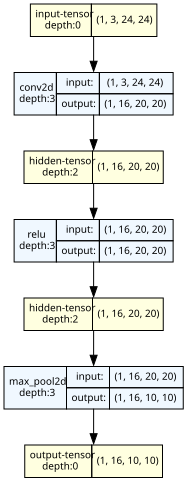

In [8]:
from torchview import draw_graph

# Show inner tensors and Functionals
model_graph = draw_graph(
    SimpleCNN(), input_size=input_size,
    graph_name='model_graph',
    hide_inner_tensors=False,
    hide_module_functions=False,
)

model_graph.visual_graph

### Depthwise Separable Convolution

For an input feature map:

$$
\mathbf{X} \in \mathbb{R}^{N \times C_{in} \times H_{in} \times W_{in}}
$$

depthwise separable convolution consists of two stages: depthwise convolution and pointwise convolution.

#### 1. Depthwise Convolution

A separate kernel is applied to each input channel:

$$
\mathbf{W}_{dw}
\in
\mathbb{R}^{C_{in} \times 1 \times K_h \times K_w}
$$

The depthwise output is computed as:

$$
Z_{n,c,i,j}
=
b^{dw}_c +
\sum_{u=0}^{K_h-1}
\sum_{v=0}^{K_w-1}
X_{n,c,(iS_h+u-P_h),(jS_w+v-P_w)}
\cdot W^{dw}_{c,u,v}
$$

The number of depthwise-convolution parameters is:

$$
N_{\text{params,dw}}
=
C_{in} \times K_h \times K_w
$$

The number of depthwise MACs per batch is:

$$
N_{\text{MACs,dw}}
=
N \times H_{out} \times W_{out}
\times C_{in} \times K_h \times K_w
$$

#### 2. Pointwise Convolution

A $1 \times 1$ convolution combines the depthwise feature maps:

$$
\mathbf{W}_{pw}
\in
\mathbb{R}^{C_{out} \times C_{in} \times 1 \times 1}
$$

The pointwise output is computed as:

$$
Y_{n,o,i,j}
=
b^{pw}_o +
\sum_{c=1}^{C_{in}}
Z_{n,c,i,j}
\cdot W^{pw}_{o,c}
$$

The number of pointwise-convolution parameters is:

$$
N_{\text{params,pw}}
=
C_{out} \times C_{in}
$$

The number of pointwise MACs per batch is:

$$
N_{\text{MACs,pw}}
=
N \times H_{out} \times W_{out}
\times C_{in} \times C_{out}
$$

#### Total Parameters and MACs

The total number of parameters is:

$$
N_{\text{params,total}}
=
C_{in} \times K_h \times K_w
+
C_{in} \times C_{out}
$$

The total number of MACs is:

$$
N_{\text{MACs,total}}
=
N \times H_{out} \times W_{out}
\left(
C_{in} \times K_h \times K_w
+
C_{in} \times C_{out}
\right)
$$

In [9]:
import torch
import torch.nn as nn
from torchinfo import summary

class SimpleCNNDepthwise(nn.Module):
    def __init__(self):
        super(SimpleCNNDepthwise, self).__init__()

        # Block 1 dengan Depthwise Separable Conv
        self.block1 = nn.Sequential( 
            # Depthwise
            nn.Conv2d(in_channels=3, out_channels=3, kernel_size=5, padding=0, groups=3, bias=False),
            # Pointwise
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=1, bias=False),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        

    def forward(self, x):
        x = self.block1(x)
        return x

model_dw = SimpleCNNDepthwise()

model_dw_stats = summary(
    model_dw, 
    input_size=(1, 3, 24, 24), 
    col_names=["input_size", "output_size", "num_params", "mult_adds"], 
    verbose=0
)
print(model_dw_stats)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Mult-Adds
SimpleCNNDepthwise                       [1, 3, 24, 24]            [1, 16, 10, 10]           --                        --
├─Sequential: 1-1                        [1, 3, 24, 24]            [1, 16, 10, 10]           --                        --
│    └─Conv2d: 2-1                       [1, 3, 24, 24]            [1, 3, 20, 20]            75                        30,000
│    └─Conv2d: 2-2                       [1, 3, 20, 20]            [1, 16, 20, 20]           48                        19,200
│    └─ReLU: 2-3                         [1, 16, 20, 20]           [1, 16, 20, 20]           --                        --
│    └─MaxPool2d: 2-4                    [1, 16, 20, 20]           [1, 16, 10, 10]           --                        --
Total params: 123
Trainable params: 123
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.05
Input size (MB): 0.01
Forwa

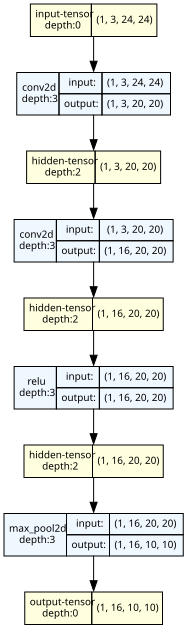

In [10]:

model_graph = draw_graph(
    SimpleCNNDepthwise(), input_size=input_size,
    graph_name='model_graph',
    hide_inner_tensors=False,
    hide_module_functions=False,
)

model_graph.visual_graph

### Comparison: Standard CNN vs. Depthwise Separable CNN

For the same input feature map and output dimensions, standard convolution and depthwise separable convolution produce an output tensor with the same shape:

$$
[N, C_{in}, H_{in}, W_{in}]
\rightarrow
[N, C_{out}, H_{out}, W_{out}]
$$

However, they require different numbers of parameters and MACs.

| Metric | Standard Convolution | Depthwise Separable Convolution |
|---|---:|---:|
| Convolution operation | One $K_h \times K_w$ convolution | Depthwise $K_h \times K_w$ convolution followed by pointwise $1 \times 1$ convolution |
| Number of parameters | $C_{out}(C_{in}K_hK_w + 1)$ | $C_{in}K_hK_w + C_{in}C_{out}$ |
| MACs per batch | $NH_{out}W_{out}C_{out}C_{in}K_hK_w$ | $NH_{out}W_{out}(C_{in}K_hK_w + C_{in}C_{out})$ |
| Output feature-map size | $[N,C_{out},H_{out},W_{out}]$ | $[N,C_{out},H_{out},W_{out}]$ |

For the standard convolution:

$$
N_{\text{params,standard}}
=
16 \times (3 \times 5 \times 5 + 1)
=
16 \times 76
=
1216
$$

For the depthwise separable convolution, the depthwise layer contains:

$$
N_{\text{params,dw}}
=
3 \times 5 \times 5
=
75
$$

The pointwise layer contains:

$$
N_{\text{params,pw}}
=
3 \times 16
=
48
$$

Therefore, the total number of parameters for depthwise separable convolution is:

$$
N_{\text{params,depthwise}}
=
(3 \times 5 \times 5)
+
(3 \times 16)
=
75 + 48
=
123
$$

The parameter reduction is:

$$
\text{Parameter Reduction}
=
\left(
1 -
\frac{N_{\text{params,depthwise}}}
{N_{\text{params,standard}}}
\right)
\times 100\%
$$

$$
=
\left(
1 -
\frac{123}{1216}
\right)
\times 100\%
=
89.88\%
$$

Thus, both approaches produce the same output feature-map dimensions, but depthwise separable convolution uses only $123$ parameters compared with $1216$ parameters in standard convolution.

In [11]:
# Comparison
params_standard = sum(p.numel() for p in model.parameters()) 

params_dw = sum(p.numel() for p in model_dw.parameters())
kehematan = ((params_standard - params_dw) / params_standard) * 100

print(f"\nCOMPARISON:")
print(f"- Standard SimpleCNN   : {params_standard} parameter")
print(f"- Depthwise SimpleCNN  : {params_dw} parameter")
print(f"- Efisiciency    : {kehematan:.2f}%")


COMPARISON:
- Standard SimpleCNN   : 1216 parameter
- Depthwise SimpleCNN  : 123 parameter
- Efisiciency    : 89.88%
